<a href="https://colab.research.google.com/github/geet29hub/Maincrafts-Internship/blob/main/task3_overfiitting_and_model_comparision_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3 - Model Validation, Overfitting Control & Hyperparameter Tuning

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


## Step 2: Load and Prepare Dataset

In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat([
    data.data,
    data.target.rename("HousePrice")
], axis=1)

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Separate Features and Target

In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]


## Step 3: Feature Scaling (Same as Task-2)

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


## Step 4: Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)


## Step 5: Detect Overfitting (Train vs Test Performance)
### Example: Decision Tree

In [8]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)


Train RMSE: 3.218325866275131e-16
Test RMSE: 0.7030445773467542


### Interpretation

- Large gap between training and test RMSE indicates overfitting.
- This is common in tree-based models without constraints.


## Step 6: Cross-Validation (Reliable Evaluation)

In [9]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()

print("Cross Validation RMSE:", cv_rmse)


Cross Validation RMSE: 0.8957031908951016


### Why Cross-Validation Matters

- Reduces dependency on one train-test split
- Provides stable and realistic performance estimates
- Used by professionals before deployment


## Step 7: Hyperparameter Tuning Using GridSearchCV

In [10]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 10, 'min_samples_split': 10}


### Best Parameters

In [11]:
grid.best_params_


{'max_depth': 10, 'min_samples_split': 10}

## Step 8: Evaluate Optimized Model

In [13]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.6454300828015771
R² Score: 0.6820992539714815


### Compare with Baseline Models

In [14]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²:", lr_r2)

print("Ridge Regression RMSE:", ridge_rmse)
print("Ridge Regression R²:", ridge_r2)

Linear Regression RMSE: 0.7455813830127761
Linear Regression R²: 0.5757877060324511
Ridge Regression RMSE: 0.745554290938461
Ridge Regression R²: 0.575818534544132


## Step 9: Model Comparison Summary Table

In [15]:
results = {
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Tuned Decision Tree"
    ],
    "RMSE": [lr_rmse, ridge_rmse, rmse],
    "R2 Score": [lr_r2, ridge_r2, r2]
}

comparison_df = pd.DataFrame(results)

comparison_df


,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.645430,0.682099


## Actual vs Predicted Plot

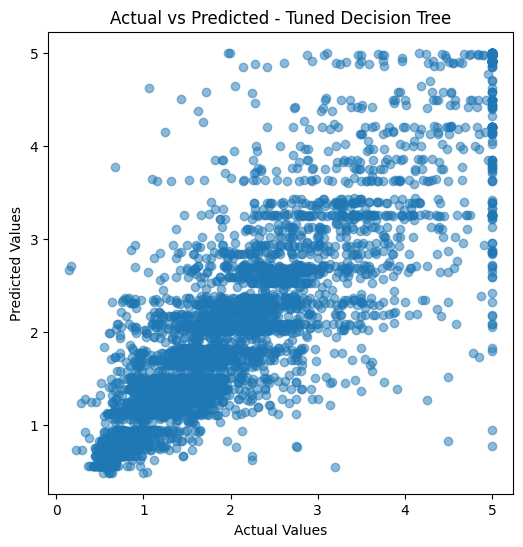

In [16]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted - Tuned Decision Tree")

plt.show()


## Conclusion

- Performed train vs test analysis for overfitting detection.
- Used Cross Validation for reliable evaluation.
- Applied GridSearchCV for hyperparameter tuning.
- Compared Linear Regression, Ridge Regression and Tuned Decision Tree.
- Selected the best model based on RMSE and R².
